In [4]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
from topocalc.skew import adjust_spacing, skew
from topocalc.gradient import gradient_d8
import matplotlib as mpl

In [2]:
def nan_a_tab(tab : np.ndarray, max_index : int, fwd : bool):
    
    a,b = tab.shape
    
    res = tab.copy()
    
    if fwd :
    
        for j in range(b):
            for i in range(j,a):
                if i > j + max_index :
                    res[i,j]=np.nan
                    
    else :
        
        for j in range(b):
            for i in range(j,0,-1):
                if i < j - max_index :
                    res[i,j]=np.nan  
                
    return res

def pyhorizon_Radius(dem : np.ndarray, dx : float, max_length : float, max_threshold : bool, fwd : bool):
    """
    From Topocalc github repo : https://github.com/USDA-ARS-NWRC/topocalc/blob/main/topocalc/horizon.py
    Modify so that radius of horizon angle investigation is in input
    
    Pure python version of the horizon function.

    NOTE: this is fast for small dem's but quite slow
    for larger ones. This is mainly to show that it
    can be done with numpy but requires a bit more to
    remove the for loop over the rows. Also, this just
    calculates the horizon in one direction, need to implement
    the rest of the horizon function for calcuating the
    horizon at an angle.

    Args:
        dem (np.ndarray): dem for the horizon
        dx (float): spacing for the dem

    Returns:
        [tuple]: cosine of the horizon angle and index
            to the horizon.
    """

    # needs to be a float
    if dem.dtype != np.float64:
        dem = dem.astype(np.float64)
        
    # Maximum index 
    max_index = int(max_length // dx)

    nrows, ncols = dem.shape
    hcos = np.zeros_like(dem)
    horizon_index = np.zeros_like(dem)

    # distance to each point
    # k=-1 because the distance to the point itself is 0
    distance = dx * np.cumsum(np.tri(ncols, ncols, k=-1), axis=0)
    col_index = np.arange(0, ncols)
        
    for n in range(nrows):
        if fwd :
            surface = dem[n, :]
        else :
            surface = dem[n, ::-1]

        m = np.repeat(surface.reshape(1, -1), ncols, axis=0)
        
        #height change
        height = np.tril(m.T - m)
   
        # slope
        slope = height / distance
        
        # Added line so that the research for maximal slope stop after max_index_columns
        if max_threshold :
            slope = nan_a_tab(tab = slope, max_index = max_index, fwd = True)
            
        hor = np.nanargmax(slope[:, :-1], axis=0)

        hor = np.append(hor, ncols-1)
        hidx = hor.astype(int)

        horizon_height_diff = surface[hidx] - surface
        horizon_distance_diff = dx * (hor - col_index)

        new_horizon = horizon_height_diff / \
            np.sqrt(horizon_height_diff**2 + horizon_distance_diff**2)

        new_horizon[new_horizon < 0] = 0
        new_horizon[np.isnan(new_horizon)] = 0

        hcos[n, :] = new_horizon
        horizon_index[n, :] = hidx

    if fwd :
        return hcos, horizon_index
    
    else :
        return hcos[:,::-1], horizon_index[:,::-1]

In [8]:
topo_params_lavey = xr.open_dataset("/home/barroisl/radiation_baseline/scripts/run_test_lavey/lavey_topo_params_30.nc")

In [13]:
topo_params_lavey

<xarray.Dataset> Size: 42MB
Dimensions:     (y: 870, x: 962)
Coordinates:
  * x           (x) float64 8kB 2.742e+05 2.742e+05 ... 2.952e+05 2.952e+05
  * y           (y) float64 7kB 4.991e+06 4.991e+06 ... 4.964e+06 4.964e+06
Data variables:
    zs          (y, x) int16 2MB ...
    slope       (y, x) float64 7MB ...
    aspect      (y, x) float64 7MB ...
    aspect_cos  (y, x) float64 7MB ...
    aspect_sin  (y, x) float64 7MB ...
    svf         (y, x) float64 7MB ...
    svf_LSLOPE  (y, x) float64 7MB ...

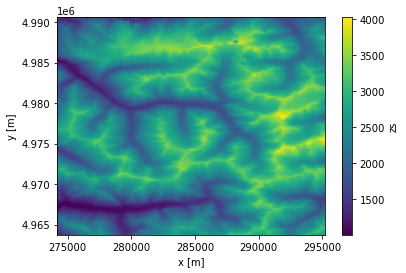

In [12]:
topo_params_lavey.zs.plot()

In [3]:
topo_params = xr.open_dataset("/home/barroisl/radiation_baseline/netcdfs/topo_params.nc")

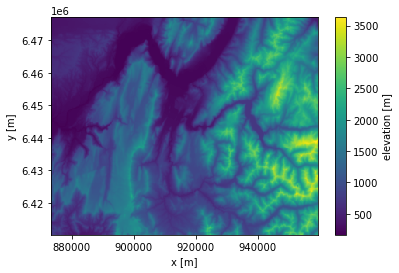

In [4]:
topo_params.ZS.plot()

In [255]:
hcos_l, horizon_index_l = pyhorizon_Radius(dem = topo_params.ZS.values, dx = 30.0, \
                                       max_length = 1000.0, max_threshold = True, fwd = True)

hcos_u, horizon_index_u = pyhorizon_Radius(dem = topo_params.ZS.values, dx = 30.0, \
                                       max_length = 1000.0, max_threshold = True, fwd = False)

/tmp/ipykernel_42088/2772762529.py:75: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/tmp/ipykernel_42088/2772762529.py:89: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \


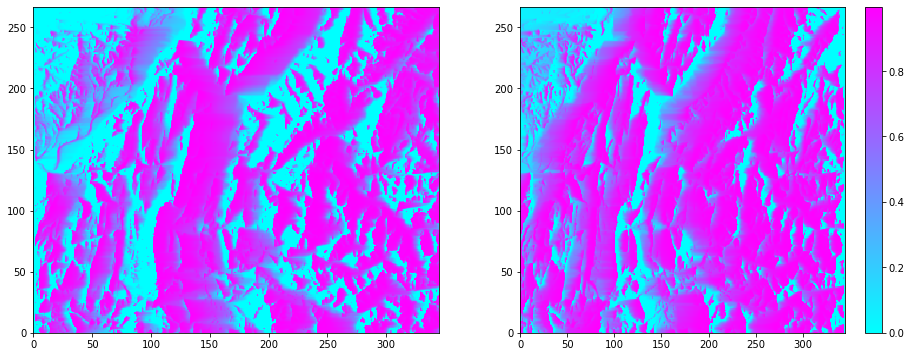

In [256]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

cax = axs[0].pcolormesh(hcos_u, cmap = 'cool')
cax = axs[1].pcolormesh(hcos_l, cmap = 'cool')
fig.colorbar(mappable = cax)

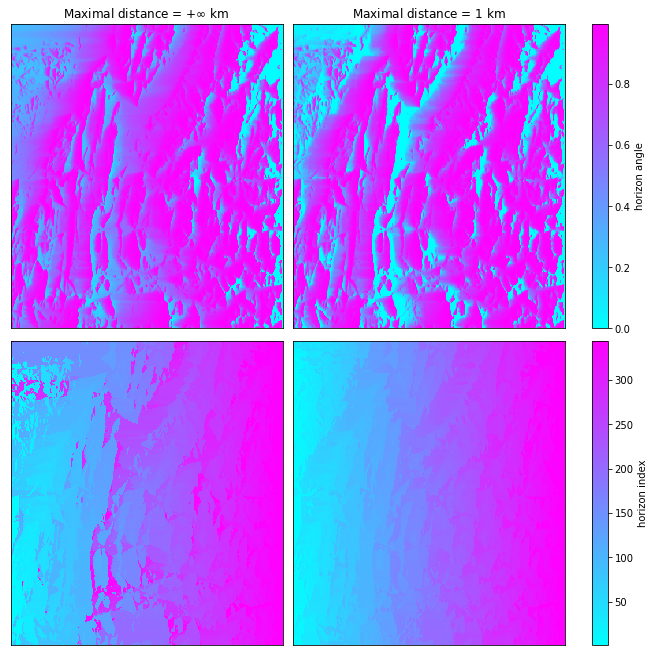

In [151]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (9,9),layout = 'constrained')

im00=axs[0,0].pcolormesh(hcos,cmap = 'cool')
im01=axs[0,1].pcolormesh(hcos_,cmap = 'cool')
fig.colorbar(mappable = im01, ax = axs[0], label = 'horizon angle')

im10=axs[1,0].pcolormesh(horizon_index,cmap = 'cool')
im11=axs[1,1].pcolormesh(horizon_index_,cmap = 'cool')
fig.colorbar(mappable = im11, ax = axs[1], label = 'horizon index')

axs[0,0].set_title('Maximal distance = $+\infty$ km')
axs[0,1].set_title('Maximal distance = $1$ km')

for i in range(4) :
    
    ax = axs[i//2,i%2]
    
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.savefig("/home/barroisl/Transect_MC_auto/Output/test_horizon_max_dist.png")

In [3]:
def skew_transpose(dem, spacing, angle):
    """Skew and transpose the dem for the given angle.
    Also calculate the new spacing given the skew.

    Arguments:
        dem {array} -- numpy array of dem elevations
        spacing {float} -- grid spacing
        angle {float} -- skew angle

    Returns:
        t -- skew and transpose array
        spacing -- new spacing adjusted for angle
    """

    spacing = adjust_spacing(spacing, np.abs(angle))
    t = skew(dem, angle, fill_min=True).transpose()

    return t, spacing

def transpose_skew(dem, spacing, angle):
    """Transpose, skew then transpose a dem for the
    given angle. Also calculate the new spacing

    Arguments:
        dem {array} -- numpy array of dem elevations
        spacing {float} -- grid spacing
        angle {float} -- skew angle

    Returns:
        t -- skew and transpose array
        spacing -- new spacing adjusted for angle
    """

    t = skew(dem.transpose(), angle, fill_min=True).transpose()
    spacing = adjust_spacing(spacing, np.abs(angle))

    return t, spacing

def horizon(azimuth : float, dem : np.ndarray, spacing : float, max_length : float, max_threshold : bool):
    """Calculate horizon angles for one direction. Horizon angles
    are based on Dozier and Frew 1990 and are adapted from the
    IPW C code.

    The coordinate system for the azimuth is 0 degrees is South,
    with positive angles through East and negative values
    through West. Azimuth values must be on the -180 -> 0 -> 180
    range.

    Arguments:
        azimuth {float} -- find horizon's along this direction
        dem {np.array2d} -- numpy array of dem elevations
        spacing {float} -- grid spacing

    Returns:
        hcos {np.array} -- cosines of angles to the horizon
    """

    if dem.ndim != 2:
        raise ValueError('horizon input of dem is not a 2D array')

    if azimuth > 180 or azimuth < -180:
        raise ValueError('azimuth must be between -180 and 180 degrees')
        

    if azimuth == 90:
        # East
        hcos,_ = pyhorizon_Radius(dem = dem, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        #hor2d_c(dem, spacing, fwd=True)

    elif azimuth == -90:
        # West
        #hcos = hor2d_c(dem, spacing, fwd=False)
        hcos,_ = pyhorizon_Radius(dem = dem, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)

    elif azimuth == 0:
        # South
        h,_ = pyhorizon_Radius(dem = dem.transpose(), dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        hcos = h.transpose()
        #hcos = hor2d_c(dem.transpose(), spacing, fwd=True)

    elif np.abs(azimuth) == 180:
        # South
        #hcos = hor2d_c(dem.transpose(), spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = dem.transpose(), dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = h.transpose()

    elif azimuth >= -45 and azimuth <= 45:
        # South west through south east
        t, spacing = skew_transpose(dem, spacing, azimuth)
        #h = hor2d_c(t, spacing, fwd=True)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        hcos = skew(h.transpose(), azimuth, fwd=False)

    elif azimuth <= -135 and azimuth > -180:
        # North west
        a = azimuth + 180
        t, spacing = skew_transpose(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = skew(h.transpose(), a, fwd=False)

    elif azimuth >= 135 and azimuth < 180:
        # North East
        a = azimuth - 180
        t, spacing = skew_transpose(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = skew(h.transpose(), a, fwd=False)

    elif azimuth > 45 and azimuth < 135:
        # South east through north east
        a = 90 - azimuth
        t, spacing = transpose_skew(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=True)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = True)
        hcos = skew(h.transpose(), a, fwd=False).transpose()

    elif azimuth < -45 and azimuth > -135:
        # South west through north west
        a = -90 - azimuth
        t, spacing = transpose_skew(dem, spacing, a)
        #h = hor2d_c(t, spacing, fwd=False)
        h,_ = pyhorizon_Radius(dem = t, dx = spacing, \
                                       max_length = max_length, max_threshold = max_threshold, fwd = False)
        hcos = skew(h.transpose(), a, fwd=False).transpose()

    else:
        ValueError('azimuth not valid')

    # sanity check
    assert hcos.shape == dem.shape

    return hcos

In [6]:
hcos_180 = horizon(azimuth = 52, dem = topo_params.ZS.values, spacing = 30.0, \
                                       max_length = 2000, max_threshold = True)
hcos_90 = horizon(azimuth = 33, dem = topo_params.ZS.values, spacing = 30.0, \
                                       max_length = 2000, max_threshold = True)

/tmp/ipykernel_8072/2772762529.py:75: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/tmp/ipykernel_8072/2772762529.py:89: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \


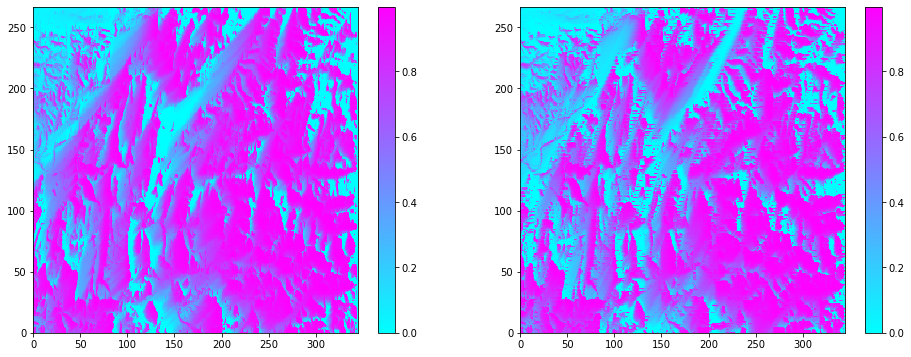

In [7]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

cax0 = axs[0].pcolormesh(hcos_180, cmap = 'cool')
fig.colorbar(mappable = cax0, ax = axs[0])
cax1 = axs[1].pcolormesh(hcos_90, cmap = 'cool')
fig.colorbar(mappable = cax1, ax = axs[1])

In [7]:
def d2r(a):
    """Angle to radians

    Arguments:
        a {float} -- angle in degrees

    Returns:
        v {float} -- angle in radians
    """
    v = a * np.pi / 180
    v = round(v, 6)  # just for testing at the moment
    return v


def viewf(dem, spacing, nangles=72, sin_slope=None, aspect=None, max_length = 20000, max_threshold = True):
    """
    Calculate the sky view factor of a dem.

    The sky view factor from equation 7b from Dozier and Frew 1990

    .. math::
        V_d \approx \frac{1}{2\pi} \int_{0}^{2\pi}\left [ cos(S) sin^2{H_\phi} 
        + sin(S)cos(\phi-A) \times \left ( H_\phi - sin(H_\phi) cos(H_\phi)
        \right )\right ] d\phi

    terrain configuration factor (tvf) is defined as:
        (1 + cos(slope))/2 - sky view factor

    Based on the paper Dozier and Frew, 1990 and modified from
    the Image Processing Workbench code base (Frew, 1990). The
    Python version of sky view factor will be an almost exact
    replication of the IPW command `viewf` minus rounding errors
    from type and linear quantization.

    Args:
        dem: numpy array for the DEM
        spacing: grid spacing of the DEM
        nangles: number of angles to estimate the horizon, defaults
                to 72 angles
        sin_slope: optional, will calculate if not provided
                    sin(slope) with range from 0 to 1
        aspect: optional, will calculate if not provided
                Aspect as radians from south (aspect 0 is toward
                the south) with range from -pi to pi, with negative
                values to the west and positive values to the east.

    Returns:
        svf: sky view factor
        tcf: terrain configuration factor

    """  # noqa

    if dem.ndim != 2:
        raise ValueError('viewf input of dem is not a 2D array')

    if nangles < 16:
        raise ValueError('viewf number of angles should be 16 or greater')

    if sin_slope is not None:
        if np.max(sin_slope) > 1:
            raise ValueError('slope must be sin(slope) with range from 0 to 1')

    # calculate the gradient if not provided
    # The slope is returned as radians so convert to sin(S)
    if sin_slope is None:
        slope, aspect = gradient_d8(
            dem, dx=spacing, dy=spacing, aspect_rad=True)
        sin_slope = np.sin(slope)

    # -180 is North
    angles = np.linspace(-180, 180, num=nangles, endpoint=False)

    # perform the integral
    cos_slope = np.sqrt((1 - sin_slope) * (1 + sin_slope))
    svf = np.zeros_like(sin_slope)
    for angle in tqdm(angles):

        # horizon angles
        hcos = horizon(angle, dem, spacing, max_length = max_length, max_threshold = max_threshold)
        azimuth = d2r(angle)

        # sin^2(H)
        sin_squared = (1 - hcos) * (1 + hcos)

        # H - sin(H)cos(H)
        h_mult = np.arccos(hcos) - np.sqrt(sin_squared) * hcos

        # cosines of difference between horizon aspect and slope aspect
        cos_aspect = np.cos(azimuth - aspect)

        # integral in equation 7b
        intgrnd = cos_slope * sin_squared + \
            sin_slope * cos_aspect * h_mult

        ind = intgrnd > 0
        svf[ind] = svf[ind] + intgrnd[ind]

    svf = svf / len(angles)

    tcf = (1 + cos_slope)/2 - svf

    return svf, tcf

In [56]:
svf_500 = viewf(dem = topo_params.ZS.values, spacing = 250.0, nangles=72, max_length = 500.0, max_threshold = True)

  0%|                                                    | 0/72 [00:00<?, ?it/s]/tmp/ipykernel_6115/2772762529.py:75: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/tmp/ipykernel_6115/2772762529.py:89: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \
100%|███████████████████████████████████████████| 72/72 [08:36<00:00,  7.17s/it]


In [57]:
svf_1000 = viewf(dem = topo_params.ZS.values, spacing = 250.0, nangles=72, max_length = 1000.0, max_threshold = True)

  0%|                                                    | 0/72 [00:00<?, ?it/s]/tmp/ipykernel_6115/2772762529.py:75: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/tmp/ipykernel_6115/2772762529.py:89: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \
100%|███████████████████████████████████████████| 72/72 [08:49<00:00,  7.36s/it]


In [46]:
svf_infty = viewf(dem = topo_params.ZS.values, spacing = 250.0, nangles=72, max_length = 200000000.0, max_threshold = True)

  0%|                                                    | 0/72 [00:00<?, ?it/s]/tmp/ipykernel_6115/2772762529.py:75: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/tmp/ipykernel_6115/2772762529.py:89: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \
100%|███████████████████████████████████████████| 72/72 [03:31<00:00,  2.94s/it]


In [58]:
topo_params['svf_500'] = (['y','x'],svf_500[0])
topo_params.svf_1000.attrs = {'units': 'ratio', 'standard_name': 'svf (500m)', 'long_name': 'Sky view factor (500m)'}

In [63]:
topo_params['svf_1000'] = (['y','x'],svf_1000[0])
topo_params.svf_1000.attrs = {'units': 'ratio', 'standard_name': 'svf (1000m)', 'long_name': 'Sky view factor (1000m)'}

In [60]:
topo_params['svf_infty'] = (['y','x'],svf_infty[0])
topo_params.svf_infty.attrs = {'units': 'ratio', 'standard_name': 'svf ($+\infty$)', 'long_name': 'Sky view factor ($+\infty$)'}

"\n# Shared indepedant colorbar\ncmap = mpl.cm.viridis\nbounds = [vmin+((vmax-vmin)/10)*i for i in range(11)]\nnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')\n\nfig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax = axs, orientation='vertical',\n             location = 'right',extend = 'both',label = '$S_{ky}VFs géométrique')\n"

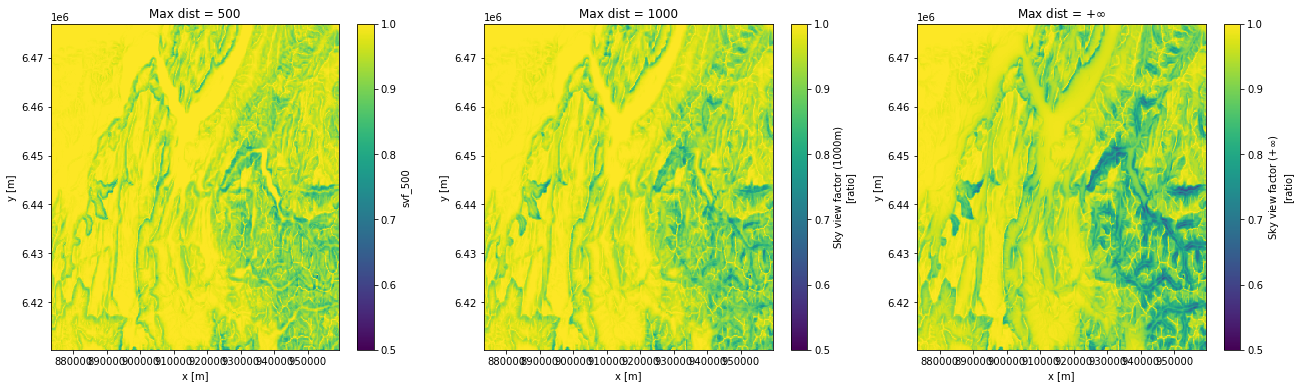

In [74]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (22,6))

vmin, vmax = 0.5,1

topo_params.svf_500.plot(ax = axs[0], cmap = 'viridis', vmin = vmin, vmax = vmax, add_colorbar = True)
topo_params.svf_1000.plot(ax = axs[1], cmap = 'viridis', vmin = vmin, vmax = vmax, add_colorbar = True)
topo_params.svf_infty.plot(ax = axs[2], cmap = 'viridis', vmin = vmin, vmax = vmax, add_colorbar = True)

titles = ['500','1000','$+\infty$']

for i in range(3):
    axs[i].set_title(f"Max dist = {titles[i]}")

"""
# Shared indepedant colorbar
cmap = mpl.cm.viridis
bounds = [vmin+((vmax-vmin)/10)*i for i in range(11)]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax = axs, orientation='vertical',
             location = 'right',extend = 'both',label = '$S_{ky}VFs géométrique')
"""

"\n# Shared indepedant colorbar\ncmap = mpl.cm.viridis\nbounds = [vmin+((vmax-vmin)/10)*i for i in range(11)]\nnorm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')\n\nfig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax = axs, orientation='vertical',\n             location = 'right',extend = 'both',label = '$S_{ky}VFs géométrique')\n"

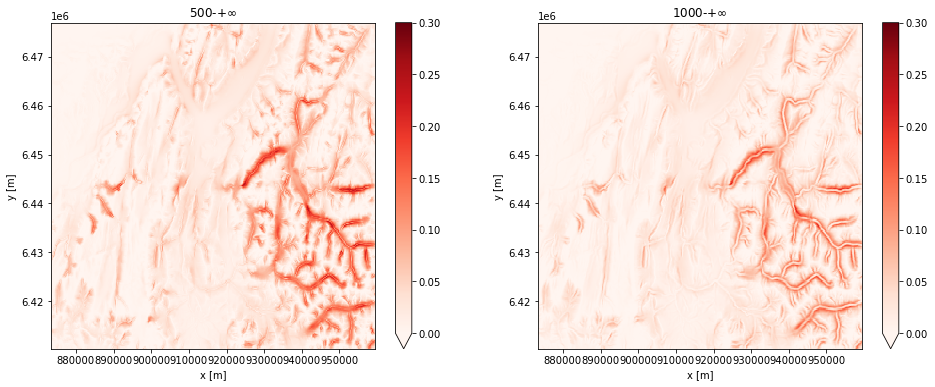

In [79]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))

vmin, vmax = 0,0.3

(topo_params.svf_500-topo_params.svf_infty).plot(ax = axs[0], cmap = 'Reds', vmin = vmin, vmax = vmax, add_colorbar = True)
(topo_params.svf_1000-topo_params.svf_infty).plot(ax = axs[1], cmap = 'Reds', vmin = vmin, vmax = vmax, add_colorbar = True)

titles = ['500','1000','$+\infty$']

for i in range(2):
    axs[i].set_title(f"{titles[i]}-{titles[2]}")

"""
# Shared indepedant colorbar
cmap = mpl.cm.viridis
bounds = [vmin+((vmax-vmin)/10)*i for i in range(11)]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax = axs, orientation='vertical',
             location = 'right',extend = 'both',label = '$S_{ky}VFs géométrique')
"""

# On cherche à reproduire un SVF sur la base des SVF par bande 

In [3]:
from Functions_lw_analysis import *
import viewfpy

In [ ]:
topo_params = xr.open_dataset("/home/barroisl/radiation_baseline/netcdfs/topo_params.nc")

svfs = SVFs_based_libre_parcours_moyen(atm = "SMLSATM", dem = topo_params.ZS.values, spacing = 250.0)

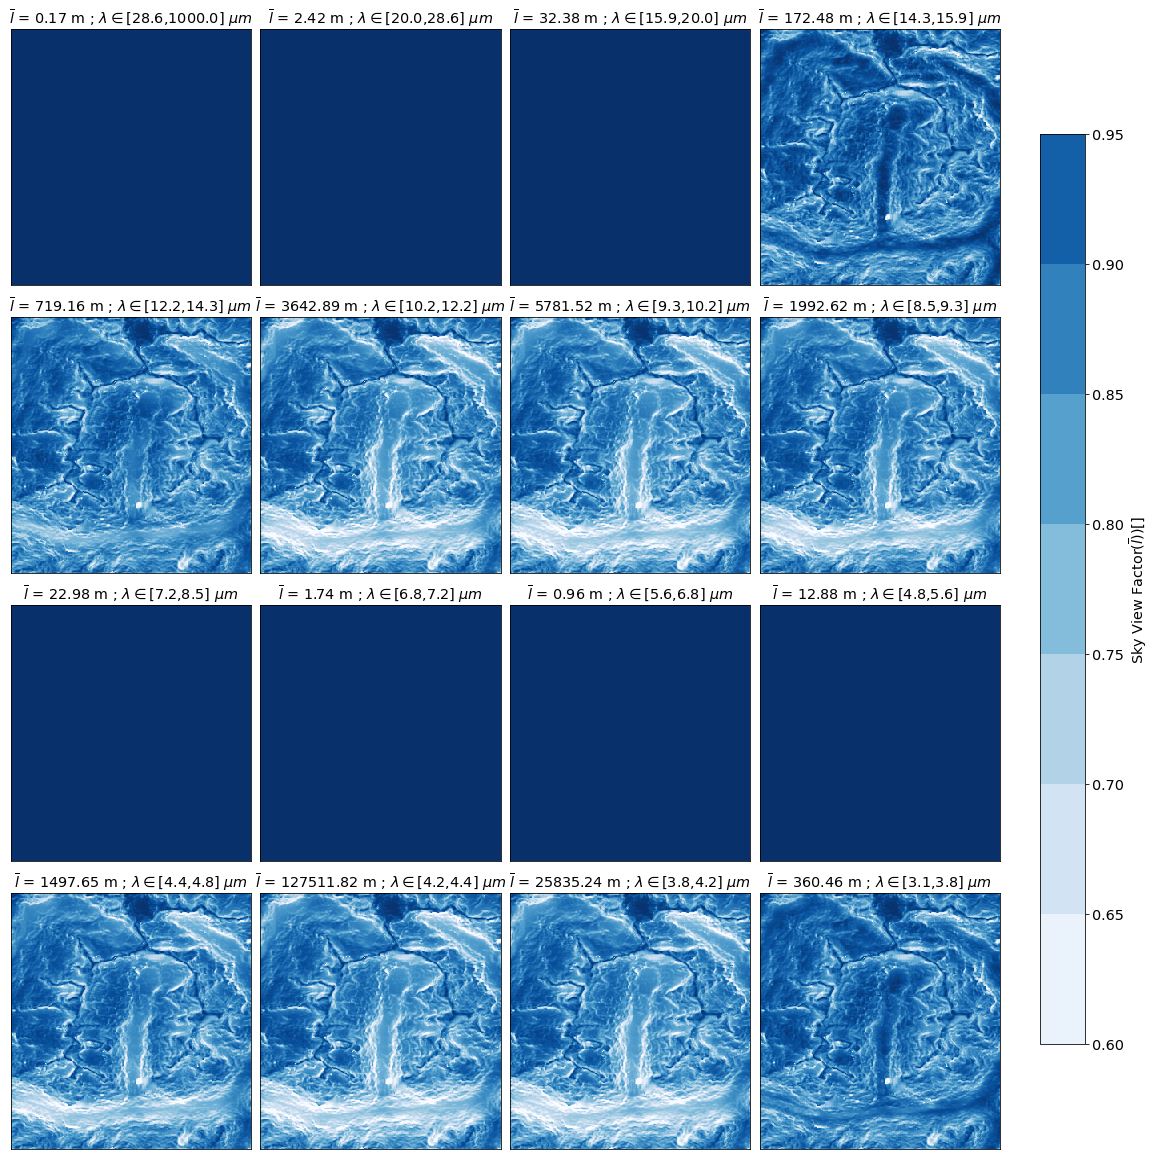

In [7]:
atm = "SMLSATM"
prop_atm = Prop_atm(atm)
arr_nb_z = prop_atm.tab_k_z_nb()

l_moy_surface = (1/arr_nb_z[0]).ravel()

LW_ints = 1e-6*1e4/prop_atm.LW_int_edges

topo_params = xr.open_dataset("/home/barroisl/radiation_baseline/netcdfs/topo_params.nc")
svfs = np.load("/home/barroisl/edstar/Simus/scripts/svfs_ecrins.npy")
#svfs = modify_svfs(topo_params=topo_params,svfs=svfs,l_moy_surface=l_moy_surface, spacing = 250.0)

plot_all_svf(svfs = svfs,LW_ints = LW_ints,l_moy_surface = l_moy_surface)

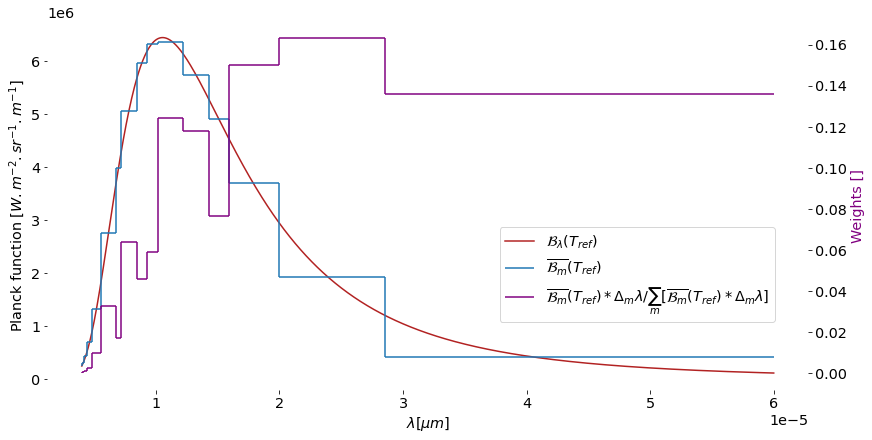

In [4]:
atm = "SMLSATM"
prop_atm = Prop_atm(atm)
LW_ints = 1e-6*1e4/prop_atm.LW_int_edges

svfs = np.load("/home/barroisl/edstar/Simus/scripts/svfs_ecrins.npy")
weights,SVF = weighted_SVFs_planck(svfs = svfs, LW_ints = LW_ints)

plot_methodo_svfm(LW_ints, weights = weights, force_save = True)

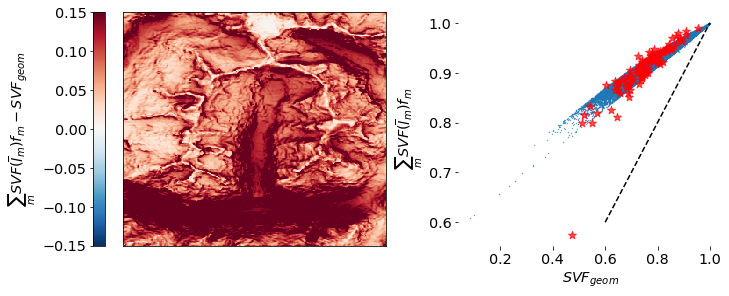

In [10]:
taux_surf = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/taux_surf.npy")
topo_params = np.loadtxt("/home/barroisl/Transect_MC_auto/camera_tgt/topo_polygon_lavey_30_100.txt")

plotting_res(SVF,svfs,taux_surf,topo_params,True)

On recommence sur un dem comparable

In [5]:
ds = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/lavey_topo_params_30_00.nc")
ds.zs

<xarray.DataArray 'zs' (y: 870, x: 965)> Size: 2MB
[839550 values with dtype=int16]
Coordinates:
  * x        (x) float64 8kB 2.741e+05 2.741e+05 ... 2.952e+05 2.952e+05
  * y        (y) float64 7kB 4.991e+06 4.991e+06 ... 4.964e+06 4.964e+06

In [47]:
svfs_ecrins = SVFs_based_libre_parcours_moyen(atm = "SMLSATM", dem = ds.zs.values[300:600,300:600], slope = ds.slope.values[300:600,300:600], spacing = 30.0)

0 0.17259170746360236
1 2.423456540691249
2 32.38218064808638
3 172.48356694917362


  0%|                                                    | 0/72 [00:00<?, ?it/s]/home/barroisl/edstar/Simus/scripts/Functions_lw_analysis.py:3841: RuntimeWarning: invalid value encountered in divide
  slope = height / distance
/home/barroisl/edstar/Simus/scripts/Functions_lw_analysis.py:3855: RuntimeWarning: invalid value encountered in divide
  new_horizon = horizon_height_diff / \
100%|███████████████████████████████████████████| 72/72 [08:08<00:00,  6.79s/it]


4 719.1597293258048


100%|███████████████████████████████████████████| 72/72 [07:59<00:00,  6.66s/it]


5 3642.8936814218437


...

100%|███████████████████████████████████████████| 72/72 [02:53<00:00,  2.40s/it]


14 25835.237772630837


100%|███████████████████████████████████████████| 72/72 [04:02<00:00,  3.37s/it]


15 360.4625107872716


100%|███████████████████████████████████████████| 72/72 [07:29<00:00,  6.25s/it]


In [64]:
np.save("/home/barroisl/edstar/Simus/scripts/svfs_ecrins.npy",svfs_ecrins)

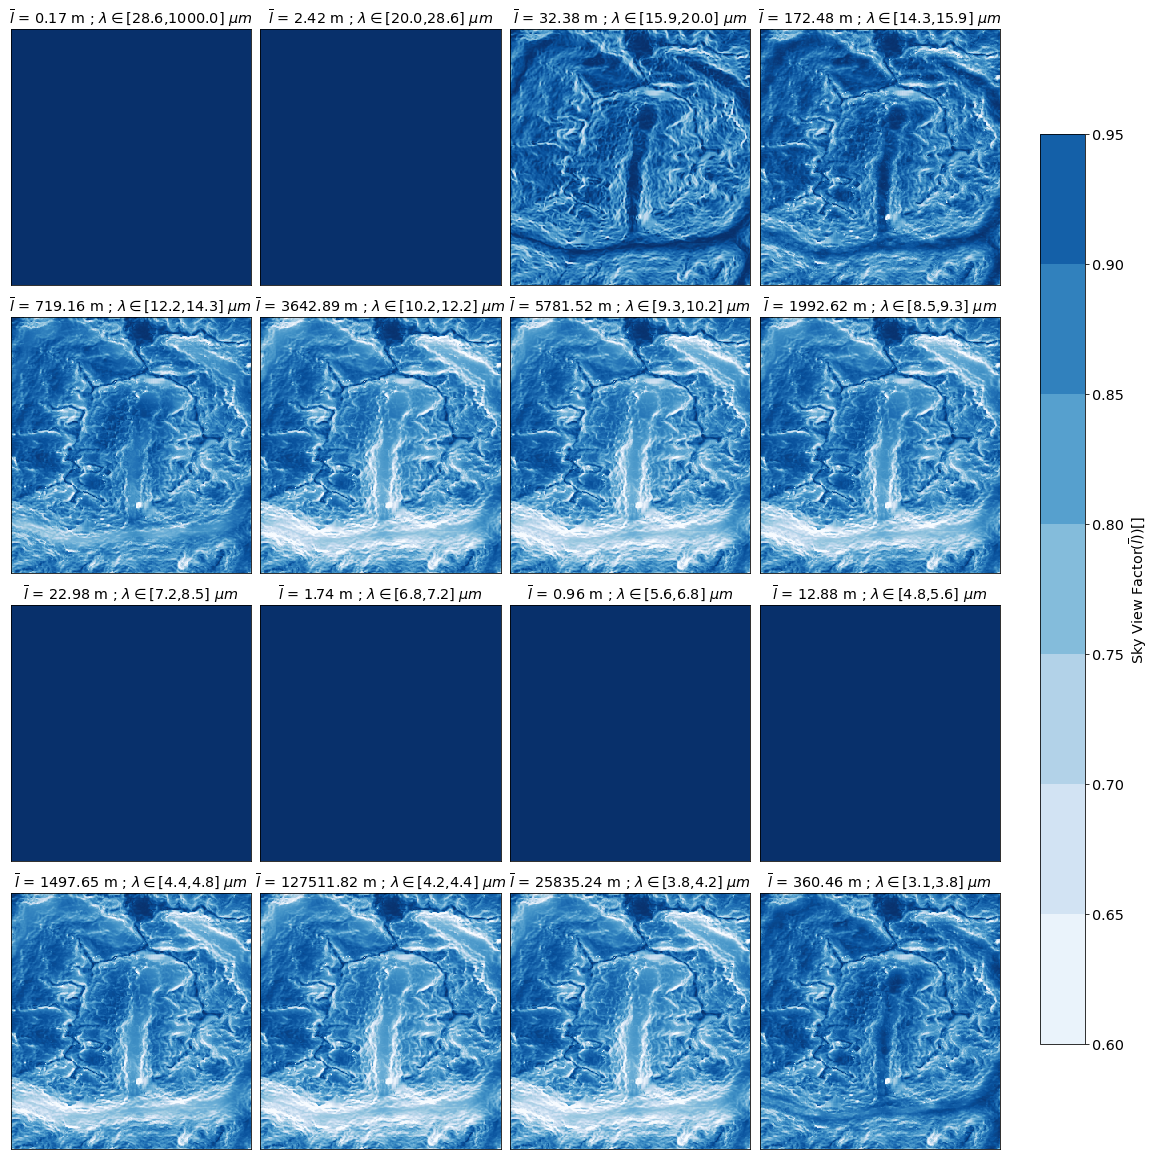

In [6]:
atm = "SMLSATM"
prop_atm = Prop_atm(atm)
arr_nb_z = prop_atm.tab_k_z_nb()

l_moy_surface = (1/arr_nb_z[0]).ravel()
LW_ints = 1e-6*1e4/prop_atm.LW_int_edges

svfs = np.load("/home/barroisl/edstar/Simus/scripts/svfs_ecrins.npy")

plot_all_svf(svfs = svfs,LW_ints = LW_ints,l_moy_surface = l_moy_surface)

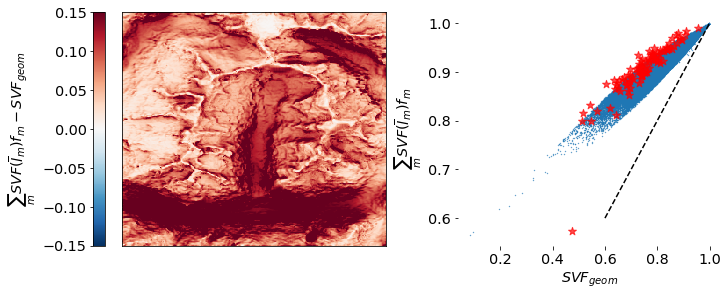

In [63]:
taux_surf = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/taux_surf.npy")
topo_params = np.loadtxt("/home/barroisl/Transect_MC_auto/camera_tgt/topo_polygon_lavey_30_100.txt")

weights,SVF = weighted_SVFs_planck(svfs = svfs, LW_ints = LW_ints)

plotting_res(SVF,svfs,taux_surf,topo_params,False)

Rendre les données exploitable pour une comparaison avec les autres SVF

In [7]:
ds = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/lavey_topo_params_30_00.nc")
ds.zs

<xarray.DataArray 'zs' (y: 870, x: 965)> Size: 2MB
[839550 values with dtype=int16]
Coordinates:
  * x        (x) float64 8kB 2.741e+05 2.741e+05 ... 2.952e+05 2.952e+05
  * y        (y) float64 7kB 4.991e+06 4.991e+06 ... 4.964e+06 4.964e+06

In [85]:
ds_crop = ds[dict(x=slice(300,600),y=slice(300,600))]
for i in range(SVF.shape[2]):
    ds_crop[f'svf_{i}'] = (['y','x'],SVF[:,:,i])
ds_crop['svfm'] = (['y','x'],np.sum(SVF,axis= 2))

In [96]:
ds_crop.to_netcdf("/home/barroisl/Transect_MC_auto/Output/ds_svfs_bande.nc")

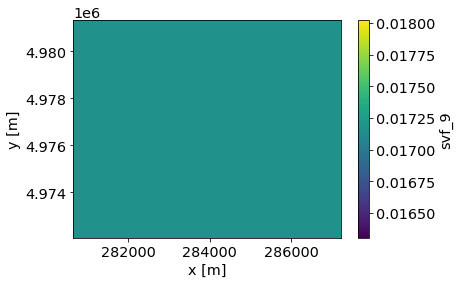

In [95]:
ds_crop.svf_9.plot()

In [67]:
cam_tgt = np.loadtxt('/home/barroisl/Transect_MC_auto/camera_tgt/polygon_lavey_30_100.txt')
topo_params = np.loadtxt('/home/barroisl/Transect_MC_auto/camera_tgt/topo_polygon_lavey_30_100.txt')
taux_surf = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/taux_surf.npy")

dtype = np.dtype([
    ("SVF_geom",    np.float64),
    ("SVF_bande",     np.float64),
    ("SVF_htrdr",     np.float64)]) 

svf_type = np.zeros(cam_tgt.shape[0],dtype = dtype)
for i in range(cam_tgt.shape[0]):
    svf_type["SVF_bande"][i] = ds_crop.interp(x = cam_tgt[i,0],y=cam_tgt[i,1], method="linear").svfm.values
    svf_type["SVF_htrdr"][i] = 1-taux_surf[i,0]
    svf_type["SVF_geom"][i] = topo_params[i,0]
    
np.save("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/SVF_types.npy",svf_type)

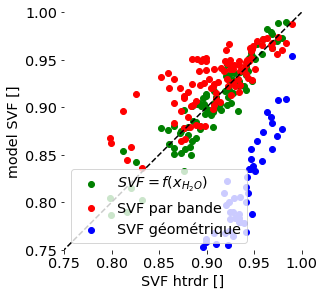

In [8]:
def plot_comparaison_model_SVFs(svf_type, force_save, save_name):
    
    coeffs_regression_x = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/linear_reg_coeffs.npy", allow_pickle = True)
    taux_surf_i = coeffs_regression_x["SMLSATM"][0]*svf_type["SVF_geom"]+coeffs_regression_x["SMLSATM"][1]
    
    fig, ax = plt.subplots(layout = 'constrained')

    ax.scatter(svf_type["SVF_htrdr"],taux_surf_i, color = 'green', label = "$SVF = f(x_{H_2O})$")
    ax.scatter(svf_type["SVF_htrdr"],svf_type["SVF_bande"], color = 'red', label = "SVF par bande")
    ax.scatter(svf_type["SVF_htrdr"],svf_type["SVF_geom"], color = 'blue', label = "SVF géométrique")
    ax.plot([0.5,1],[0.5,1],linestyle = 'dashed',color = 'k')

    ax.legend()
    ax.set_aspect('equal')
    ax.set_xlim((0.75,1))
    ax.set_ylim((0.75,1))
    ax.set_xlabel("SVF htrdr []")
    ax.set_ylabel("model SVF []")
    ax.spines[['left','right', 'top', 'bottom']].set_visible(False)
    
    if force_save :
        plt.savefig(f"/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/{save_name}.png")
 
svf_type = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/SVF_types.npy",allow_pickle = True)
plot_comparaison_model_SVFs(svf_type = svf_type, force_save = True, save_name = "comparaison_SVFS")

In [9]:
def compute_bande_LW_surf(svfs: np.ndarray, Ts : float, LW_ints: np.ndarray, epsilon_s = 0.98)->np.ndarray:
    
    mask_lbd_sup = LW_ints > 60e-6
    mask_lbd_inf = LW_ints < 4e-6
    LW_ints[mask_lbd_sup] = 60e-6
    LW_ints[mask_lbd_inf] = 4e-6
    
    weights = np.zeros(svfs.size)
    for i in range(svfs.size):
        
        lbd_1,lbd_2 = LW_ints[i,1],LW_ints[i,0]
       
        if lbd_1 != lbd_2 :
            wavelengths = np.linspace(lbd_1,lbd_2,10)
            mean_planck = np.mean(Planck_law(wavelength = wavelengths,\
                                            temperature = Ts))*(lbd_2-lbd_1)
            weights[i] = mean_planck
            
        else :
            weights[i] = 0
        
    LW_surf = np.sum(np.pi*(1-svfs)*epsilon_s*weights)
                
    return LW_surf

def compute_bande_LW_atm(svfs: np.ndarray, T2m : float, LW_ints: np.ndarray, ka : np.array)->float:
    
    mask_lbd_sup = LW_ints > 60e-6
    mask_lbd_inf = LW_ints < 4e-6
    LW_ints[mask_lbd_sup] = 60e-6
    LW_ints[mask_lbd_inf] = 4e-6
    
    weights = np.zeros(svfs.size)
    for i in range(svfs.size):
        
        lbd_1,lbd_2 = LW_ints[i,1],LW_ints[i,0]
       
        if lbd_1 != lbd_2 :
            wavelengths = np.linspace(lbd_1,lbd_2,10)
            mean_planck = np.mean(Planck_law(wavelength = wavelengths,\
                                            temperature = T2m))*(lbd_2-lbd_1)
            weights[i] = mean_planck
            
        else :
            weights[i] = 0
        
    LW_surf = np.sum(np.pi*svfs*ka*weights)
                
    return LW_surf

def compute_LW_all_cams_models(ds_svf : xr.Dataset, ds_ecrins : xr.Dataset, atm):
    
    cam_tgt = np.loadtxt('/home/barroisl/Transect_MC_auto/camera_tgt/polygon_lavey_30_100.txt')
    topo_params = np.loadtxt('/home/barroisl/Transect_MC_auto/camera_tgt/topo_polygon_lavey_30_100.txt')
    taux_surf = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/taux_surf.npy")
    flux_surf = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/flux_surf.npy")
    flux_atm = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/flux_atm.npy")
    coeffs_regression_x = np.load("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/linear_reg_coeffs.npy", allow_pickle = True)
    coeffs_e = np.load("/home/barroisl/Transect_MC_auto/Output/z_profiles/coeffs_emissivity.npy")
    
    svf_x = coeffs_regression_x["SMLSATM"][0]*topo_params[:,0]+coeffs_regression_x["SMLSATM"][1]
    emisivities = coeffs_e["SMLSATM"][0]*topo_params[:,-1]+coeffs_e["SMLSATM"][1]
    
    prop_atm = Prop_atm("SMLSATM")
    arr_nb_z = prop_atm.tab_k_z_nb()
    kas = arr_nb_z[0].ravel()
    T_profile = prop_atm.profiles(variable = 'T')
    z_profile = prop_atm.profiles(variable = 'z')
        
    dtype = np.dtype([
        ("surface",    np.float64),
        ("atmo",     np.float64),
        ("total",     np.float64)])  
    LW_bande = np.zeros(cam_tgt.shape[0],dtype = dtype)
    LW_geom = np.zeros(cam_tgt.shape[0],dtype = dtype)
    LW_htrdr = np.zeros(cam_tgt.shape[0],dtype = dtype)
    LW_x = np.zeros(cam_tgt.shape[0],dtype = dtype)
    for i in tqdm(range(cam_tgt.shape[0])):
        x = cam_tgt[i,0]
        y = cam_tgt[i,1]
        z = cam_tgt[i,2]
        
        ds_svf_interp = ds_svf.interp(x = x,y = y, method = 'linear')
        svfs = np.array([ds_svf_interp[f"svf_{i}"].values for i in range(16)])
        
        ########### Flux surface ############
        ## Bande ##
        Ts = ds_ecrins.interp(x = x, y = y, method = 'linear').ts.values
        
        LW_bande["surface"][i] = compute_bande_LW_surf(svfs = svfs, Ts = Ts, LW_ints = LW_ints)
        
        ## htrdr ##
        LW_htrdr["surface"][i] = flux_surf[i,0]
        
        ## geom ##
        LW_geom["surface"][i] = (1-topo_params[i,0])*0.98*5.67e-8*Ts**4
        
        ## SVF_x ##
        LW_x["surface"][i] = (1-svf_x[i])*0.98*5.67e-8*Ts**4
        
        ########### Flux atm ############
        ## bande ##
        Ta = np.interp(z,z_profile,T_profile)
        
        LW_bande["atmo"][i] = compute_bande_LW_atm(svfs = svfs, T2m = Ta, LW_ints = LW_ints, ka = np.full_like(kas,emisivities[i]))
        
        ## htrdr ##
        LW_htrdr["atmo"][i] = flux_atm[i,0]
        
        ## geom ##
        LW_geom["atmo"][i] = topo_params[i,0]*emisivities[i]*5.67e-8*Ta**4
        
        ## SVF_x ##
        LW_x["atmo"][i] = svf_x[i]*emisivities[i]*5.67e-8*Ta**4
        
        ########### Total ############
        ## bande ##
        LW_bande["total"][i] = LW_bande["surface"][i] + LW_bande["atmo"][i]
        
        ## geom ##
        LW_geom["total"][i] = LW_geom["surface"][i] + LW_geom["atmo"][i]
        
        ## htrdr ##
        LW_htrdr["total"][i] = LW_htrdr["surface"][i] + LW_htrdr["atmo"][i]
        
        ## SVF_x ##
        LW_x["total"][i] = LW_x["surface"][i] + LW_x["atmo"][i]
        
    return LW_bande,LW_geom,LW_htrdr,LW_x

In [10]:
ds_svf = xr.open_dataset("/home/barroisl/Transect_MC_auto/Output/ds_svfs_bande.nc")
ds_ecrins = xr.open_dataset("/home/barroisl/Transect_MC_auto/topographie/lavey_topo_params_30.nc")
ds_ecrins['ts'] = (['y','x'], altit_T(dem = ds_ecrins['zs'].values, 
                                        T0 = 273.15,
                                        z0 = 1300, 
                                        lapse_rate = 0.0))

LW_bande,LW_geom,LW_htrdr,LW_x = compute_LW_all_cams_models(ds_svf = ds_svf, ds_ecrins = ds_ecrins, atm = "SMLSATM")

100%|█████████████████████████████████████████| 100/100 [00:17<00:00,  5.84it/s]


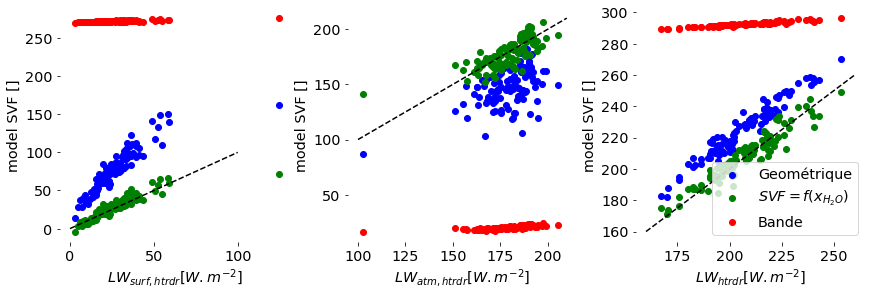

In [11]:
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4),layout = 'constrained')

axs[0].scatter(LW_htrdr["surface"],LW_geom["surface"],color = 'blue', marker = 'o')
axs[0].scatter(LW_htrdr["surface"],LW_x["surface"],color = 'green', marker = 'o')
axs[0].scatter(LW_htrdr["surface"],LW_bande["surface"],color = 'red', marker = 'o')
axs[0].plot([0,100],[0,100],c='k',linestyle = 'dashed')

axs[1].scatter(LW_htrdr["atmo"],LW_geom["atmo"],color = 'blue', marker = 'o')
axs[1].scatter(LW_htrdr["atmo"],LW_x["atmo"],color = 'green', marker = 'o')
axs[1].scatter(LW_htrdr["atmo"],LW_bande["atmo"],color = 'red', marker = 'o')
axs[1].plot([100,210],[100,210],c='k',linestyle = 'dashed')

axs[2].scatter(LW_htrdr["total"],LW_geom["total"],color = 'blue', marker = 'o', label = "Geométrique")
axs[2].scatter(LW_htrdr["total"],LW_x["total"],color = 'green', marker = 'o', label = "$SVF=f(x_{H_2O})$")
axs[2].scatter(LW_htrdr["total"],LW_bande["total"],color = 'red', marker = 'o', label = "Bande")
axs[2].plot([160,260],[160,260],c='k',linestyle = 'dashed')

xlabels = ["$LW_{surf,htrdr} [W.m^{-2}]$","$LW_{atm,htrdr} [W.m^{-2}]$","$LW_{htrdr} [W.m^{-2}]$"]
ylabels = ["$LW_{surf,model} [W.m^{-2}]$","$LW_{atm,model} [W.m^{-2}]$","$LW_{model} [W.m^{-2}]$"]

for i in range(3):
    ax = axs[i]
    #ax.set_aspect('equal')
    ax.set_xlabel(xlabels[i])
    ax.set_ylabel("model SVF []")
    ax.spines[['left','right', 'top', 'bottom']].set_visible(False)
    
axs[2].legend()

plt.savefig("/home/barroisl/Transect_MC_auto/Output/lavey_30_100_atms_00/models_flux.png")